# 09 — Ext Data Fig 7e: IDO1 in myeloid cells, high vs low IRC
Myeloid = CD14 monocytes, CD16 monocytes, cDC2; patients only.

## Step 15.1 — IDO1 expression in myeloid cells


  P1   P2   P3   P4   P5   P6   P7   P8 
4503 4066 6245 1823  236 3672 2366 2505 

group,n_cells,pct_expressing,mean_expr
<fct>,<int>,<dbl>,<dbl>
high_IRC,16637,0.9,0.009
low_IRC,8779,1.2,0.013


Cell-level Wilcoxon P: 0.0241 


sample,group,n_cells,pct_expressing,mean_expr
<chr>,<fct>,<int>,<dbl>,<dbl>
P1,high_IRC,4503,1.7,0.016
P2,high_IRC,4066,0.6,0.007
P3,high_IRC,6245,0.6,0.006
P4,high_IRC,1823,0.5,0.005
P5,low_IRC,236,5.1,0.092
P6,low_IRC,3672,0.2,0.002
P7,low_IRC,2366,1.4,0.014
P8,low_IRC,2505,2.1,0.021


Patient-level P (4 vs 4): 0.486 


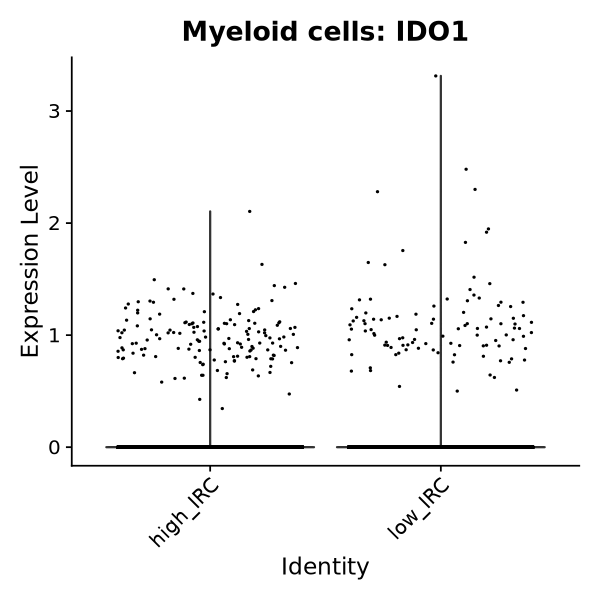

In [1]:
suppressPackageStartupMessages({ library(Seurat); library(tidyverse) })
proj <- "/mnt/d/project3_IFN-I"

obj <- readRDS(file.path(proj, "results/objects/04_annotated_rpca.rds"))
my  <- subset(obj, subset = celltype %in% c("CD14 monocytes", "CD16 monocytes", "cDC2") &
                            group %in% c("high_IRC", "low_IRC"))
rm(obj); invisible(gc())
my$group <- factor(my$group, levels = c("high_IRC", "low_IRC"))
table(my$sample)

ido <- FetchData(my, vars = c("IDO1", "sample", "group"))

# Cell level
ido |> group_by(group) |>
  summarise(n_cells = n(), pct_expressing = round(100 * mean(IDO1 > 0), 1),
            mean_expr = round(mean(IDO1), 3), .groups = "drop")
cat("Cell-level Wilcoxon P:", signif(wilcox.test(IDO1 ~ group, data = ido)$p.value, 3), "\n")

# Patient level
ido_pt <- ido |> group_by(sample, group) |>
  summarise(n_cells = n(), pct_expressing = round(100 * mean(IDO1 > 0), 1),
            mean_expr = round(mean(IDO1), 3), .groups = "drop")
ido_pt
cat("Patient-level P (4 vs 4):", signif(wilcox.test(mean_expr ~ group, data = ido_pt, exact = TRUE)$p.value, 3), "\n")
write_csv(ido_pt, file.path(proj, "results/tables/09_extfig7e_ido1_per_patient.csv"))

options(repr.plot.width = 5, repr.plot.height = 5)
p7e <- VlnPlot(my, features = "IDO1", group.by = "group", pt.size = 0.1) +
  labs(title = "Myeloid cells: IDO1") + NoLegend()
p7e
ggsave(file.path(proj, "figures/trackB/09_extfig7e_ido1_myeloid.png"), p7e, width = 5, height = 5, dpi = 150)